<a href="https://colab.research.google.com/github/PDM-15/AML-2026/blob/master/25.08.2026/Decision_Tree_socialnwAds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Social Network Ads - Dataset

Data preprocessing

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Loading
drive.mount('/content/drive')

data = pd.read_csv("drive/My Drive/Dataset/Social_Network_Ads.csv")
dataset = data

data.info()

X = dataset.iloc[:,[2,3]].values

y = dataset.iloc[:,4].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 45)

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


Decisison Tree

Accuracy: 86.0 %
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        62
           1       0.83      0.79      0.81        38

    accuracy                           0.86       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.86      0.86      0.86       100

User will not buy


[Text(0.5, 0.9583333333333334, 'x[0] <= 0.62\nentropy = 0.934\nsamples = 300\nvalue = [195, 105]'),
 Text(0.27976190476190477, 0.875, 'x[1] <= 0.604\nentropy = 0.646\nsamples = 218\nvalue = [182, 36]'),
 Text(0.3898809523809524, 0.9166666666666667, 'True  '),
 Text(0.10714285714285714, 0.7916666666666666, 'x[0] <= -0.125\nentropy = 0.182\nsamples = 182\nvalue = [177, 5]'),
 Text(0.08333333333333333, 0.7083333333333334, 'entropy = 0.0\nsamples = 122\nvalue = [122, 0]'),
 Text(0.13095238095238096, 0.7083333333333334, 'x[1] <= 0.021\nentropy = 0.414\nsamples = 60\nvalue = [55, 5]'),
 Text(0.10714285714285714, 0.625, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.15476190476190477, 0.625, 'x[1] <= 0.4\nentropy = 0.663\nsamples = 29\nvalue = [24, 5]'),
 Text(0.13095238095238096, 0.5416666666666666, 'x[1] <= 0.137\nentropy = 0.592\nsamples = 28\nvalue = [24, 4]'),
 Text(0.047619047619047616, 0.4583333333333333, 'x[0] <= 0.173\nentropy = 0.371\nsamples = 14\nvalue = [13, 1]'),
 Text

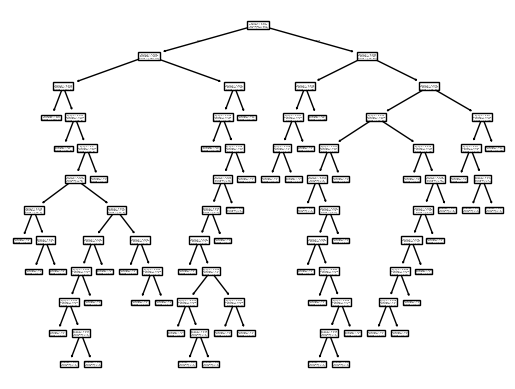

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics
from sklearn import tree
#Decision tree object of DecisionTreeClassifier class
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 45) #We can give gini as criterion as well
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

y_test
y_pred
cm

#Accuracy = (cm[0][0] +cm[1][1])

prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", prediction * 100, "%")

print(classification_report(y_test, y_pred))

new_individual = np.array([[29, 80000]])
new_individual_scaled = sc_X.transform(new_individual)
prediction = classifier.predict(new_individual_scaled)

if prediction[0] == 1:
  print("User will buy")
else:
  print("User will not buy")

tree.plot_tree(classifier)